# Project card

**The paper:** 
>Volatility of Mutator Phenotypes at Single
Cell Resolution

**The data object:**
>Novel mutation count per cell division for all lineages

**The random variable chosen:**

>Mutation count

**What the paper does:**
>Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**
> 2-poisson model https://link.springer.com/rwe/10.1007/978-0-387-39940-9_920

**Parameters and assumptions:**
> total count of cells = N

**The forward simulation:**
> Monte-Carlo simulation; Grid search to find paramters for 2 poisson

**The parameterization/fitting:**

**What/if the model adds to the paper:**

**Model limitations/how it breaks:**

***

## To do
> Change mean mutations in summary statistics to per base pair per division instead of per cell division.
Mutations depend on size of DNA and not count of cells or cell divisions

---

### Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

### Functions

In [2]:
def mean(counts):
    """The mean of a list of counts."""
    return sum(counts) / len(counts)

def std_dev(counts):
    """The standard deviation of a list of counts."""
    m = mean(counts)
    total = 0.0
    for x in counts:
        total = total + (x - m) ** 2
    return math.sqrt(total / len(counts))

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)

def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total


def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total


def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

### Data

#### 1. Read Files

In [4]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna().astype(int)) for column in df.columns]
counts = [y for x in lineages for y in x]

genome_size = 1.02E+07
genome_size_lineages = [10926041,10034503,10099122,10889177,11040018,9684038,10209723,10826564]

# Print the data
print("Data Matrix:")
print(df,"\n")
print("Lineage Cell Division Counts:")
print("\n".join(str(lin) for lin in lineages), "\n")
print("Flattened Counts:")
print(counts, len(counts))

Data Matrix:
           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN 

Lineage Cell Division Counts:
[0, 2, 0, 3, 2, 4, 1, 3, 4]
[3, 7, 6, 0, 0, 2, 3, 4, 4, 6, 5, 1, 0]
[2, 2, 0, 3, 0, 0, 1, 1, 4, 5, 3, 0, 9, 4, 2]
[2, 3, 1

#### 2. Summary Statistics

Mean: 2.7411764705882353 mutations/cell division
Mean: 2.6874279123414073e-07 mutations/cell division/bp
Standard Deviation: 2.3919125558306864
Variance: 5.721245674740486
Variance is higher than mean, thus overdispersed


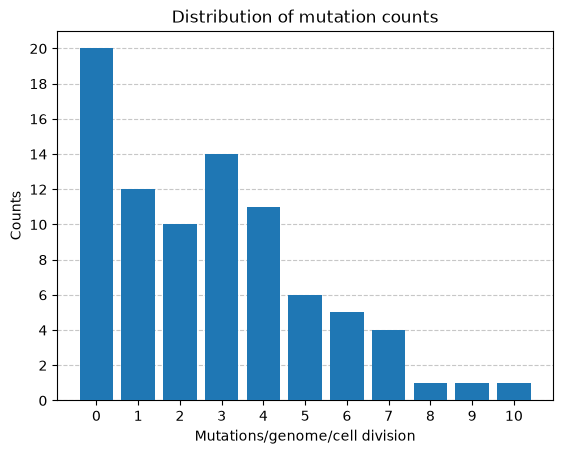

In [5]:
max_mutation_count = int(max(counts))
mutation_counts = [0] * (max_mutation_count + 1)

for count in counts:
    mutation_counts[int(count)] += 1 

mean_count = mean(counts)
sigma = std_dev(counts)
variance = sigma ** 2
mutation_rate = mu/genome_size
print(f"Mean: {mu} mutations/cell division")
print(f"Mean: {mutation_rate} mutations/cell division/bp")
print(f"Standard Deviation: {sigma}")
print(f"Variance: {variance}")
print("Variance is higher than mean, thus overdispersed")

mutation_prob =  [ mutation_count/sum(mutation_counts) for mutation_count in mutation_counts ]

fig, ax = plt.subplots()
ax.bar(range(len(mutation_counts)), mutation_counts, zorder=3)
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Counts")
ax.set_xticks(range(0,11))
ax.set_yticks(range(0,22,2))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.set_title("Distribution of mutation counts")
plt.show()

#### 3. Models

##### 3.1 1-Poisson Model

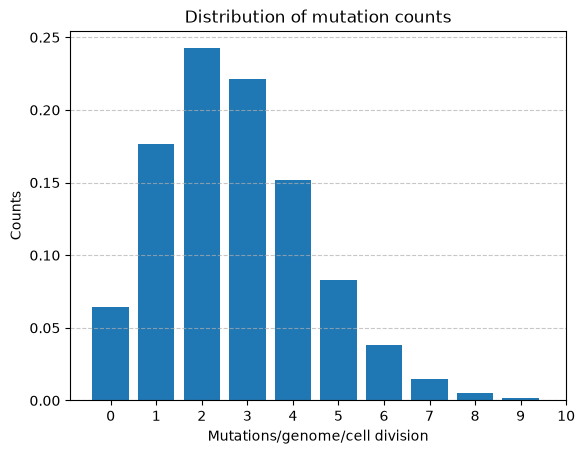

In [6]:
k_counts = range(max_mutation_count)
y = [0] * len(k_counts)
for i in range(len(k_counts)):
    y[i] += poisson(k_counts[i], mu)

# print(likelihood(counts, mu))
for i in range(len(thetas)):
    thetas[i] = theta_start + (i * dtheta)
    # likelihoods[i] = likelihood(counts, thetas[i])
    nlls[i] = nll(counts, thetas[i])
    
best = position_of_min(nlls)
theta_hat = thetas[best]
best_score = nlls[best]
print("theta_hat", theta_hat)
print("NLL Score", best_score)
print("Mean: ", mu)
print("NLL Score", nll(counts, mu))

fig, ax = plt.subplots()
ax.plot(thetas, nlls)
ax.plot(theta_hat, best_score, 'ro')
ax.set_xlabel("Theta")
ax.set_ylabel("NLL Score")
ax.set_title("NLL Score by Sweeping")
plt.show()

[9.444444444444445, 10.625, 8.5, 10.625, 10.625, 12.142857142857142, 9.444444444444445, 9.444444444444445, 10.625, 9.444444444444445, 8.5, 9.444444444444445, 9.444444444444445, 9.444444444444445, 9.444444444444445, 12.142857142857142, 10.625, 10.625, 8.5, 10.625, 10.625, 9.444444444444445, 10.625, 10.625, 10.625, 12.142857142857142, 9.444444444444445, 10.625, 10.625, 8.5, 10.625, 10.625, 10.625, 10.625, 10.625, 7.083333333333333, 10.625, 9.444444444444445, 8.5, 9.444444444444445, 10.625, 9.444444444444445, 12.142857142857142, 7.7272727272727275, 9.444444444444445, 10.625, 9.444444444444445, 9.444444444444445, 9.444444444444445, 7.7272727272727275, 9.444444444444445, 10.625, 9.444444444444445, 9.444444444444445, 10.625, 9.444444444444445, 10.625, 9.444444444444445, 7.7272727272727275, 10.625, 10.625, 8.5, 10.625, 8.5, 12.142857142857142, 9.444444444444445, 12.142857142857142, 8.5, 10.625, 9.444444444444445, 10.625, 10.625, 10.625, 9.444444444444445, 12.142857142857142, 12.14285714285714

(array([ 10.,  29., 115., 296.,   0., 391.,   0., 153.,   0.,   6.]),
 array([ 6.53846154,  7.30128205,  8.06410256,  8.82692308,  9.58974359,
        10.3525641 , 11.11538462, 11.87820513, 12.64102564, 13.40384615,
        14.16666667]),
 <BarContainer object of 10 artists>)

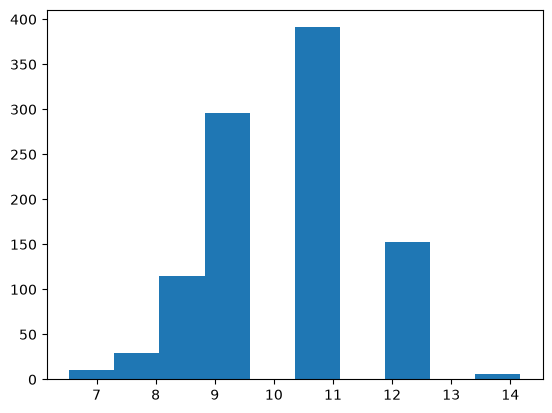

In [33]:
# Monte-Carlo for 1 Poisson

# Probabiity of mutation per base is your theta. Give a genome size and divide the cell.


def simuate_count(lam, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = poisson(0, lam)
    k = 0
    while r > total:
        k += 1
        total = total + poisson(k, lam)
    return k, state


cell_divisions = 85
state = seed

def experiment(lam, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simuate_count(lam, state)
        simulated_counts[i] = (sim_count)

    simulated = [0] * (max(simulated_counts) + 1)
    for x in simulated_counts:
        simulated[x] += 1
    return simulated, state

simulated_means = []

for i in range(1000):
    simulated, state = experiment(mu, cell_divisions, state)
    simulated_means.append(mean(simulated))
print(simulated_means)
fig, ax = plt.subplots()
ax.hist(simulated_means)

In [8]:
# Negative Binomial





In [9]:
# Baysian

#### Backwards - estimating the model’s parameter/s

### 1-Poisson Model

In [22]:
mu_candidates = np.arange(0.02, 5, 0.02).tolist()            

scores_nll_ = [0.0] * len(mu_candidates)

for i in range(len(mu_candidates)):
  total = 0
  for j in range(len(lineages)):
    total += nll(lineages[j], mu_candidates[i]*genome_size_lineages[j]*10**(-7))
  scores_nll_[i] = total

position_of_min_nll = position_of_min(scores_nll_)
mu_hat = mu_candidates[position_of_min_nll]
print(f"Estimated mutation rate (mu_hat): {mu_hat} e-7 mutations/cell division/bp")

Estimated mutation rate (mu_hat): 2.62 e-7 mutations/cell division/bp


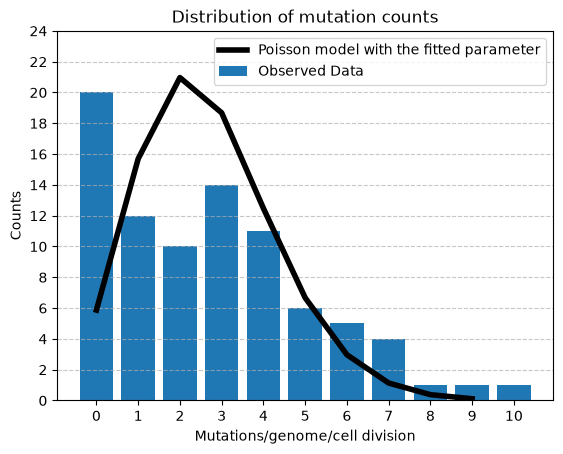

In [45]:
k_counts = range(max_mutation_count)
y = [0] * len(k_counts)
for i in range(len(k_counts)):
    y[i] += poisson(k_counts[i], mu_hat*genome_size*10**(-7))

y = [n * 85 for n in y]
plt.plot(k_counts, y,color="black", label="Poisson model with the fitted parameter",linewidth=4)
plt.bar(range(len(mutation_counts)), mutation_counts, label="Observed Data")
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11))
plt.yticks(range(0,25,2))
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

### 2 Poisson Model

In [7]:
def nll_mix_poisson(counts, lambda1, lambda2, pi):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(pi * poisson(x, lambda1) + (1-pi) * poisson(x, lambda2))
    return total

lambda1 = np.arange(0, 2, 0.02).tolist()
lambda2 = np.arange(1 , 5, 0.02).tolist()
pi = np.arange(0.05 , 0.95, 0.05).tolist()

flag = True
for k in pi:
  for j in lambda2:
    for i in lambda1:
        nll_mix_poisson_score = nll_mix_poisson(counts,i,j,k)
        if flag:
            minimum = nll_mix_poisson_score
            lambda1_hat = i
            lambda2_hat = j
            pi_hat = k
            flag = False
        elif nll_mix_poisson_score < minimum:
            minimum = nll_mix_poisson_score
            lambda1_hat = i
            lambda2_hat = j
            pi_hat = k

print("lambda1_hat =", round(lambda1_hat, 3))
print("lambda2_hat =", round(lambda2_hat, 3))
print("pi_hat =", round(pi_hat, 3))

KeyboardInterrupt: 

In [ ]:
y_mix_poisson_lik = [0] * len(counts)
y_mix_poisson_test = [0] * len(counts)

for i in range(len(counts)):
    y_mix_poisson_lik[i] += pi_hat * poisson(counts[i], lambda1_hat) + (1-pi_hat) * poisson(counts[i], lambda2_hat)
    y_mix_poisson_test[i] += 0.35 * poisson(counts[i], 0.5) + (1-0.35) * poisson(counts[i], 3.5)
    #y_mix_poisson_test[i] += 0.2 * poisson(counts[i], lambda1_hat) + (1-0.2) * poisson(counts[i], lambda2_hat)


y_mix_poisson_lik = [x*N for x in y_mix_poisson_lik]
y_mix_poisson_test = [x*N for x in y_mix_poisson_test]

plt.figure(figsize=(14, 5))
#plt.bar(counts, y_mix_poisson)
plt.bar(np.array(range((max_mutation_count)+1)) - 0.3, mutation_counts, width=0.3, label='Data', color='red')
plt.bar(np.array(counts) , y_mix_poisson_lik, width=0.3, label='MAX LIKE', color='blue')
plt.bar(np.array(counts) + 0.3, y_mix_poisson_test, width=0.3, label='TEST', color='green')
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

NameError: name 'N' is not defined

### Parameter uncertainty

In [10]:
# AIC

In [11]:
# 1-Poisson

In [12]:
# 2-Poisson

In [13]:
# 3-Poisson